In [2]:
import pandas as pd
import cobra
import memote
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm


In [ ]:

mitocore1= cobra.io.read_sbml_model('/Users/benjaminreyes/Desktop/Masterarbeit/MitoCore_for_Disease_Modelling/Output_Models_MitoCore/Mitocore_Original.xml')
mitocore2= cobra.io.read_sbml_model('/Users/benjaminreyes/Desktop/Masterarbeit/MitoCore_for_Disease_Modelling/Output_Models_MitoCore/Mitocore_Preliminary.xml')
mitocore3= cobra.io.read_sbml_model('/Users/benjaminreyes/Desktop/Masterarbeit/MitoCore_for_Disease_Modelling/Output_Models_MitoCore/Mitocore_MitoMAMMAL.xml')
mitocore4= cobra.io.read_sbml_model('/Users/benjaminreyes/Desktop/Masterarbeit/MitoCore_for_Disease_Modelling/Output_Models_MitoCore/Mitocore_aligned_to_Human1.xml')

In [3]:
def get_ec_code(model):
    """ extract ec-codes and get total number of ec-codes in the model"""
    curation_ec = []

    for reaction in model.reactions:
        annotations = getattr(reaction, '_annotation', {})
        ec_data = annotations.get('ec-code', [])

        # normalize -> ensure ec_data is always a list
        if isinstance(ec_data, str):
            ec_data = [ec_data]

        # iterate over str ec-code in a list made of str 
        for ec_code in ec_data:
            if isinstance(ec_code, str):
                curation_ec.append(ec_code)
    
    return curation_ec

def get_gpr_elements(model):
    """ extract GPR elements and split in 'or' to get enzyme complexes and isoenzymes count"""
    gpr_count= []
    for reaction in model.reactions:
        gpr= reaction.gene_reaction_rule
        # 'or' separates isoenzymes in the GPR
        gpr_elements= gpr.split('or')
        for gpr_element in gpr_elements:
            if isinstance(gpr_element, str) and gpr_element not in ['', 'Unknown', 'None', 'none', 'NoneType']:
                gpr_count.append(gpr_element)
            elif isinstance(gpr_element, list) and gpr_element not in ['', 'Unknown', 'None', 'none', 'NoneType']:
                gpr_count.extend(gpr_element)
    return gpr_count
        
def get_database_ids_count(model, component, database):
    """Extract the count of identifiers for a specific database in a specific core component."""
    
    db_ids = []
    components = getattr(model, component)

    for comp in components:
        annotations = comp.annotation
        db_data = annotations.get(database)

        if not db_data:
            continue

        # normalize to list
        if isinstance(db_data, str):
            db_ids.append(db_data)
        elif isinstance(db_data, list):
            db_ids.extend(db_data)

    return db_ids


In [4]:
df = pd.DataFrame({
        "MitoCore Original": { 'ec-codes':len(get_ec_code(mitocore1)),
                    'Enzyme complex and isoenzymes':len(get_gpr_elements(mitocore1)), 
                    'UniProt genes':len(get_database_ids_count(mitocore1, 'genes', 'uniprot')),
                    'Memote Score': int(36)
        },
        "MitoCore Preliminary curation": { 'ec-codes':len(get_ec_code(mitocore2)),
                    'Enzyme complex and isoenzymes':len(get_gpr_elements(mitocore2)), 
                    'UniProt genes':len(get_database_ids_count(mitocore2, 'genes', 'uniprot')),
                    'Memote Score': int(36)
        },
        "MitoCore MitoMammal curation": { 'ec-codes':len(get_ec_code(mitocore3)),
                    'Enzyme complex and isoenzymes':len(get_gpr_elements(mitocore3)), 
                    'UniProt genes':len(get_database_ids_count(mitocore3, 'genes', 'uniprot')),
                    'Memote Score': int(40)
        },
        "MitoCore aligned to Human1": { 'ec-codes':len(get_ec_code(mitocore4)),
                    'Enzyme complex and isoenzymes':len(get_gpr_elements(mitocore4)), 
                    'UniProt genes':len(get_database_ids_count(mitocore4, 'genes', 'uniprot')),
                    'Memote Score': int(65)
        },        
})
print(df)

                               MitoCore Original  \
ec-codes                                     354   
Enzyme complex and isoenzymes                479   
UniProt genes                                  0   
Memote Score                                  36   

                               MitoCore Preliminary curation  \
ec-codes                                                 354   
Enzyme complex and isoenzymes                            479   
UniProt genes                                            387   
Memote Score                                              36   

                               MitoCore MitoMammal curation  \
ec-codes                                                357   
Enzyme complex and isoenzymes                           490   
UniProt genes                                           387   
Memote Score                                             40   

                               MitoCore aligned to Human1  
ec-codes                                  

/var/folders/9p/_1828r2n5gb11k82139j3hz00000gn/T/ipykernel_21586/1491203730.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("YlGnBu", len(models))


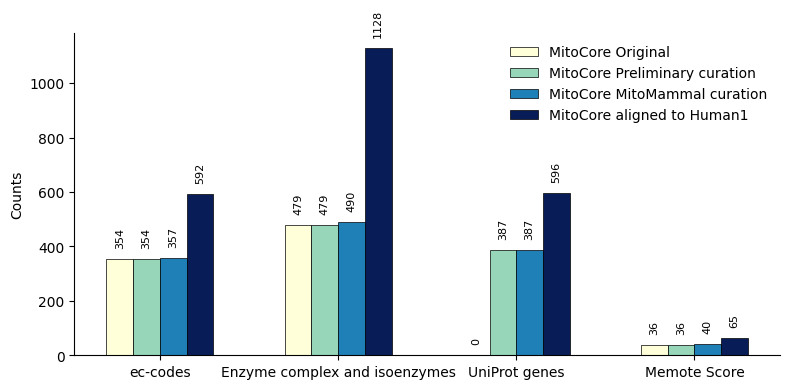

In [ ]:
metrics = df.index[df.index != "model"]
models = df.columns
data = df.loc[metrics]

# Colormap
cmap = cm.get_cmap("YlGnBu", len(models))
colors = [cmap(i) for i in range(len(models))]

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(metrics))
width = 0.15

for i, (model, color) in enumerate(zip(models, colors)):
    bars = ax.bar(
        x + i * width,
        data[model],
        width,
        label=model,
        color=color,
        edgecolor="black",
        linewidth=0.5,
    )
    
    # Add value labels above each bar, rotated 90°
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,  # center x
            height + 40,                        # slightly above the bar
            f"{int(height)}",                    # label text
            ha="center",                         # horizontal alignment
            va="bottom",                         # vertical alignment
            fontsize=8,
            rotation=90                          # rotate text 90 degrees
        )

# Axis formatting
ax.set_ylabel("Counts")
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels(metrics, rotation=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)

#plt.title("Comparison AutoPACMEN Metrics During MitoCore Curation")
plt.tight_layout()
plt.show()
plt.savefig("/Users/benjaminreyes/Desktop/Masterarbeit/MitoCore_for_Disease_Modelling/Output_Models_MitoCore/MitoCore_Curation_Comparison.png", dpi=300)

In [6]:
for reaction in mitocore1.reactions:
    if reaction.id in ['CV_MitoCore', 'PCFLOPm', 'PSFLIPm', 'PEFLIPm']:
        print(reaction.id,'has GPR', reaction.gene_reaction_rule)

CV_MitoCore has GPR (ENSG00000152234 and ENSG00000110955 and ENSG00000165629 and ENSG00000099624 and ENSG00000124172 and ENSG00000116459 and ENSG00000167863 and ENSG00000169020 and ENSG00000154723 and ENSG00000241468 and ENSG00000167283 and ENSG00000249222 and ENSG00000241837 and ENSG00000198899 and ENSG00000228253 and ENSG00000159199) or (ENSG00000152234 and ENSG00000110955 and ENSG00000165629 and ENSG00000099624 and ENSG00000124172 and ENSG00000116459 and ENSG00000167863 and ENSG00000169020 and ENSG00000154723 and ENSG00000241468 and ENSG00000167283 and ENSG00000249222 and ENSG00000241837 and ENSG00000198899 and ENSG00000228253 and ENSG00000135390) or (ENSG00000152234 and ENSG00000110955 and ENSG00000165629 and ENSG00000099624 and ENSG00000124172 and ENSG00000116459 and ENSG00000167863 and ENSG00000169020 and ENSG00000154723 and ENSG00000241468 and ENSG00000167283 and ENSG00000249222 and ENSG00000241837 and ENSG00000198899 and ENSG00000228253 and ENSG00000154518)
PCFLOPm has GPR (ENS